<a href="https://colab.research.google.com/github/z-serra/PythonNotes4ML/blob/main/BasicRecommenderSystemsNotes.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme()

import zipfile
import urllib.request

url = "https://files.grouplens.org/datasets/movielens/ml-100k.zip"
urllib.request.urlretrieve(url, "ml-100k.zip")

with zipfile.ZipFile("ml-100k.zip", "r") as zip_ref:
    zip_ref.extractall()

ratings = pd.read_csv('ml-100k/u.data', sep='\t',
                      names=['user_id','item_id','rating','timestamp'])

movies = pd.read_csv('ml-100k/u.item', sep='|', encoding='latin-1',
                     names=['item_id','title'] + list(range(22)))

df = pd.merge(ratings, movies[['item_id','title']], on='item_id')

df.head()

,user_id,item_id,rating,timestamp,title
0,196,242,3,881250949,Kolya (1996)
1,186,302,3,891717742,L.A. Confidential (1997)
2,22,377,1,878887116,Heavyweights (1994)
3,244,51,2,880606923,Legends of the Fall (1994)
4,166,346,1,886397596,Jackie Brown (1997)


In [2]:
df.groupby('title')['rating'].mean().sort_values(ascending=False).head()

,rating
title,
Aiqing wansui (1994),5.0
Entertaining Angels: The Dorothy Day Story (1996),5.0
Santa with Muscles (1996),5.0
Prefontaine (1997),5.0
They Made Me a Criminal (1939),5.0


In [3]:
df.groupby('title')['rating'].count().sort_values(ascending=False).head()

,rating
title,
Star Wars (1977),583
Contact (1997),509
Fargo (1996),508
Return of the Jedi (1983),507
Liar Liar (1997),485


In [4]:
ratings = pd.DataFrame(df.groupby('title')['rating'].mean())

ratings['Num of Ratings'] = pd.DataFrame(df.groupby('title')['rating'].count())

ratings.head()

,rating,Num of Ratings
title,,
'Til There Was You (1997),2.333333,9
1-900 (1994),2.600000,5
101 Dalmatians (1996),2.908257,109
12 Angry Men (1957),4.344000,125
187 (1997),3.024390,41


<Axes: >

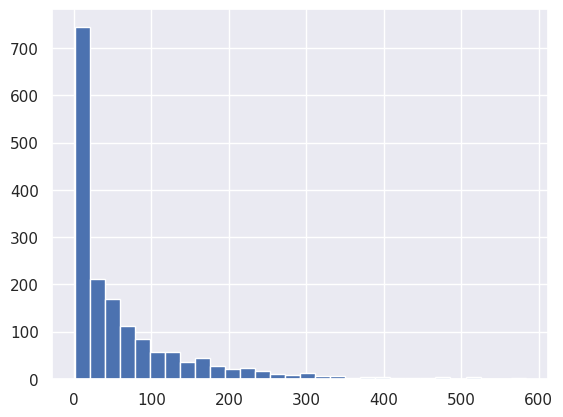

In [5]:
ratings['Num of Ratings'].hist(bins=30)

<Axes: >

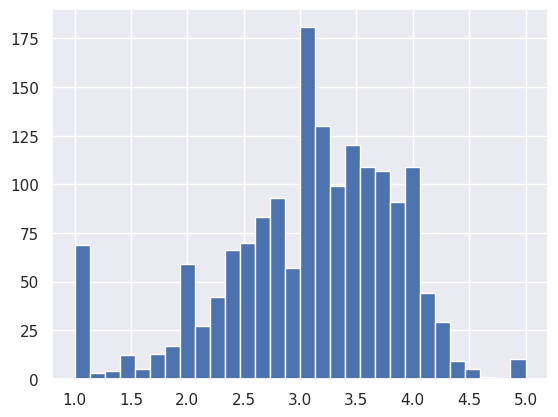

In [6]:
ratings['rating'].hist(bins=30)

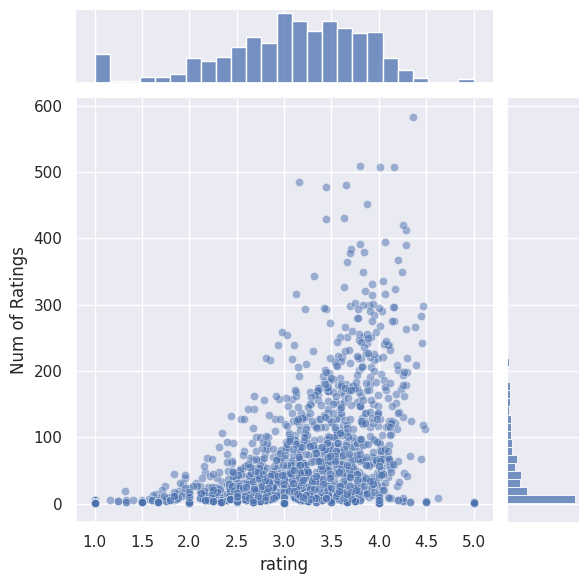

In [7]:
sns.jointplot(x='rating', y='Num of Ratings', data=ratings, alpha=0.5)

In [8]:
movie_matrix = df.pivot_table(index='user_id', columns='title', values='rating')

movie_matrix.head()

title,'Til There Was You (1997),1-900 (1994),101 Dalmatians (1996),12 Angry Men (1957),187 (1997),2 Days in the Valley (1996),"20,000 Leagues Under the Sea (1954)",2001: A Space Odyssey (1968),3 Ninjas: High Noon At Mega Mountain (1998),"39 Steps, The (1935)",...,Yankee Zulu (1994),Year of the Horse (1997),You So Crazy (1994),Young Frankenstein (1974),Young Guns (1988),Young Guns II (1990),"Young Poisoner's Handbook, The (1995)",Zeus and Roxanne (1997),unknown,Á köldum klaka (Cold Fever) (1994)
user_id,,,,,,,,,,,,,,,,,,,,,
1,NaN,NaN,2.0,5.0,NaN,NaN,3.0,4.0,NaN,NaN,...,NaN,NaN,NaN,5.0,3.0,NaN,NaN,NaN,4.0,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,2.0,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,NaN,NaN,2.0,NaN,NaN,NaN,NaN,4.0,NaN,NaN,...,NaN,NaN,NaN,4.0,NaN,NaN,NaN,NaN,4.0,NaN


In [9]:
ratings.sort_values('Num of Ratings', ascending=False).head()

,rating,Num of Ratings
title,,
Star Wars (1977),4.358491,583
Contact (1997),3.803536,509
Fargo (1996),4.155512,508
Return of the Jedi (1983),4.007890,507
Liar Liar (1997),3.156701,485


In [10]:
star_wars = movie_matrix['Star Wars (1977)']
contact = movie_matrix['Contact (1997)']

star_wars.head(), contact.head()

(user_id
 1    5.0
 2    5.0
 3    NaN
 4    5.0
 5    4.0
 Name: Star Wars (1977), dtype: float64,
 user_id
 1    5.0
 2    3.0
 3    2.0
 4    5.0
 5    NaN
 Name: Contact (1997), dtype: float64)

In [11]:
movie_matrix.corrwith(star_wars).head()

/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2922: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2923: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2914: RuntimeWarning: Degrees of freedom <= 0 for slice
  c = cov(x, y, rowvar, dtype=dtype)
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2773: RuntimeWarning: divide by zero encountered in divide
  c *= np.true_divide(1, fact)
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2773: RuntimeWarning: invalid value encountered in multiply
  c *= np.true_divide(1, fact)


,0
title,
'Til There Was You (1997),0.872872
1-900 (1994),-0.645497
101 Dalmatians (1996),0.211132
12 Angry Men (1957),0.184289
187 (1997),0.027398


In [12]:
similar_to_star_wars = movie_matrix.corrwith(star_wars)

In [13]:
similar_to_contact = movie_matrix.corrwith(contact)

In [14]:
corr_star_wars = pd.DataFrame(similar_to_star_wars, columns=['Correlation'])
corr_star_wars.dropna(inplace=True)
corr_star_wars.sort_values('Correlation', ascending=False).head()

,Correlation
title,
Hollow Reed (1996),1.0
Stripes (1981),1.0
No Escape (1994),1.0
Man of the Year (1995),1.0
Cosi (1996),1.0


In [15]:
corr_star_wars = corr_star_wars.join(ratings['Num of Ratings'])
corr_star_wars.head()

,Correlation,Num of Ratings
title,,
'Til There Was You (1997),0.872872,9
1-900 (1994),-0.645497,5
101 Dalmatians (1996),0.211132,109
12 Angry Men (1957),0.184289,125
187 (1997),0.027398,41


In [16]:
corr_star_wars[corr_star_wars['Num of Ratings'] > 100].sort_values('Correlation', ascending=False).head()

,Correlation,Num of Ratings
title,,
Star Wars (1977),1.000000,583
"Empire Strikes Back, The (1980)",0.747981,367
Return of the Jedi (1983),0.672556,507
Raiders of the Lost Ark (1981),0.536117,420
Austin Powers: International Man of Mystery (1997),0.377433,130


In [17]:
corr_contact = pd.DataFrame(similar_to_contact, columns=['Correlation'])
corr_contact.dropna(inplace=True)
corr_contact = corr_contact.join(ratings['Num of Ratings'])
corr_contact[corr_contact['Num of Ratings'] > 100].sort_values('Correlation', ascending=False).head()

,Correlation,Num of Ratings
title,,
Contact (1997),1.000000,509
Philadelphia (1993),0.446509,137
"Mask, The (1994)",0.418328,129
Young Guns (1988),0.388839,101
Sling Blade (1996),0.384840,136
